In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import seaborn as sns
import numpy as np

# Plot for daily mean/median for year 20XX:

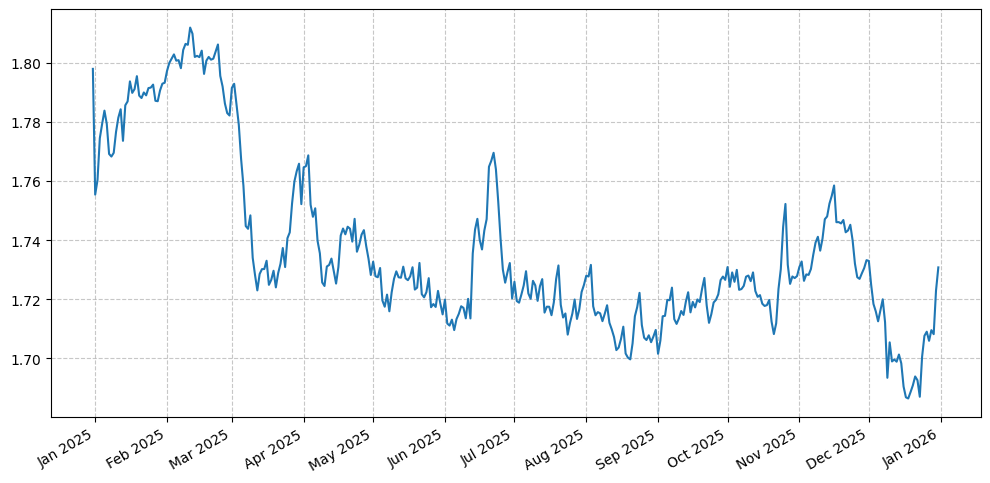

In [3]:
df = pd.read_csv(r"D:\data\derived\national_daily_last\national_daily_last_2025.csv")
#print(df.head())

df["day"] = pd.to_datetime(df["day"])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["day"], df["e5_mean_last"])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Same with seaborn library
### Experiment:

In [4]:
# defining the color scheme for the plots (VS Code like):
plt.rcParams.update({
    "axes.facecolor": "#1e1e1e",
    "figure.facecolor": "#1e1e1e",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333"
})

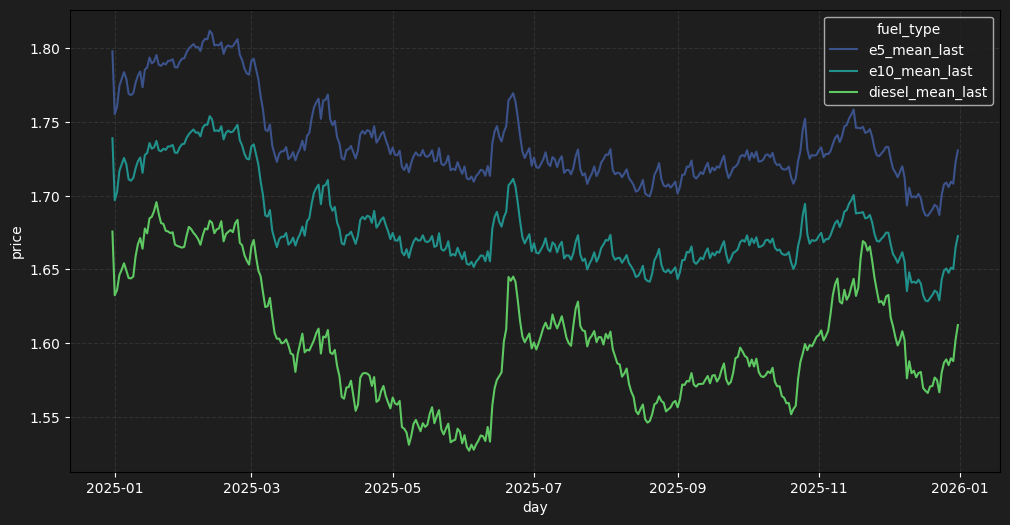

In [5]:
df_long = df.melt(id_vars=["day"],
                  value_vars=["e5_mean_last", "e10_mean_last", "diesel_mean_last"],
                  var_name="fuel_type",
                  value_name="price")

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=df_long, x="day", y="price", hue="fuel_type", palette="viridis")
plt.grid(True, color="#444444", linestyle="--", alpha=0.5)

plt.show()

# Yahoo Finance oil data:

In [5]:
ticker = "BZ=F"
start = "2025-01-01"
end = "2026-01-01"

df_oil = yf.download(ticker, start=start, end=end, interval="1d", auto_adjust=False)

oil_daily = (
    df_oil
    .reset_index()
    .rename(columns={"Date": "day", "Close": "oil_close"})
    [["day", "oil_close"]]
)

oil_daily["day"] = pd.to_datetime(oil_daily["day"]).dt.date
oil_daily.to_csv(r"D:\data\derived\oil_daily\brent_daily_2025.csv", index=False)

[*********************100%***********************]  1 of 1 completed


# =======================
# Start of the analysis
# =======================

In [ ]:
fuel_path = r"D:\data\derived\national_daily_last\national_daily_last_2025.csv"
fuel = pd.read_csv(fuel_path)

fuel["day"] = pd.to_datetime(fuel["day"])
fuel = fuel.sort_values("day")

# Examople: using e5_mean_last as fuel price, but you can choose any other column
fuel = fuel[["day", "e5_mean_last"]].rename(columns={"e5_mean_last": "fuel_price"})

# ===============================================================================

ticker = "BZ=F"
start = "2025-01-01"
end   = "2026-01-01"

oil_raw = yf.Ticker(ticker).history(start=start, end=end, interval="1d")
oil = (oil_raw.reset_index()
              .rename(columns={"Date": "day", "Close": "oil_close"})
              [["day", "oil_close"]])
oil["day"] = pd.to_datetime(oil["day"]).dt.normalize()

# day index to same format for both dataframes
fuel["day"] = pd.to_datetime(fuel["day"]).dt.date
oil["day"] = pd.to_datetime(oil["day"]).dt.tz_localize(None).dt.date

print(fuel.head())
print(oil.head())

          day  fuel_price
0  2024-12-31    1.797952
1  2025-01-01    1.755391
2  2025-01-02    1.760303
3  2025-01-03    1.774491
4  2025-01-04    1.779331
          day  oil_close
0  2025-01-02  75.930000
1  2025-01-03  76.510002
2  2025-01-06  76.300003
3  2025-01-07  77.050003
4  2025-01-08  76.160004


In [7]:
# merge of fuel and oil dataframes on "day", keeping all fuel rows and filling oil_close forward
merged_fill = fuel.merge(oil, on="day", how="left").sort_values("day")
merged_fill["oil_close"] = merged_fill["oil_close"].ffill()
merged_fill = merged_fill.dropna(subset=["oil_close", "fuel_price"]).reset_index(drop=True)

print(merged_fill.head(15))

           day  fuel_price  oil_close
0   2025-01-02    1.760303  75.930000
1   2025-01-03    1.774491  76.510002
2   2025-01-04    1.779331  76.510002
3   2025-01-05    1.783821  76.510002
4   2025-01-06    1.779326  76.300003
5   2025-01-07    1.769160  77.050003
6   2025-01-08    1.768269  76.160004
7   2025-01-09    1.769531  76.919998
8   2025-01-10    1.776616  79.760002
9   2025-01-11    1.781457  79.760002
10  2025-01-12    1.784282  79.760002
11  2025-01-13    1.773594  81.010002
12  2025-01-14    1.785621  79.919998
13  2025-01-15    1.786945  82.029999
14  2025-01-16    1.793713  81.290001


## Computing
Log-Return:
$$r_t = \log(P_t) - \log(P_{t-1}) = \log\left(\frac{P_t}{P_{t-1}}\right)$$
therefore we get approximate %-change (for smaller changes):
$$r_t \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$
thus the process is now $\approx$ stationary.
Now you can use the Cross-Correlation-Function (CCF):
$$\text{corr}(r_t^{fuel}, r_{t-k}^{oil})$$

In [17]:
# Calculate log returns for fuel and oil to make them comparable and to analyze their
# relationship in terms of percentage changes rather than absolute price levels.
df_dummy = merged_fill.copy()

df_dummy["r_fuel"] = np.log(df_dummy["fuel_price"]).diff()
df_dummy["r_oil"] = np.log(df_dummy["oil_close"]).diff()

# first row is NaN due to diff(), so we drop it along with any other potential NaNs in the return columns
df_dummy = df_dummy.dropna(subset=["r_fuel", "r_oil"]).reset_index(drop=True)

K = 20  # maximum lag for Cross-Correlation Function (CCF)

for k in range(K + 1):
    df_dummy[f"r_oil_lag{k}"] = df_dummy["r_oil"].shift(k) # maybe use vector for better performance?

# drop rows with NaN in any of the lagged oil return columns or in the fuel return column
lag_cols = [f"r_oil_lag{k}" for k in range(K + 1)]
data = df_dummy.dropna(subset=lag_cols + ["r_fuel"]).copy()

# Cross-Correlation Function (CCF):
ccf = []
for k in range(K + 1):
    c = data["r_fuel"].corr(data[f"r_oil_lag{k}"])
    ccf.append({"lag_days": k, "corr": c})

ccf_df = pd.DataFrame(ccf)
print(ccf_df)

    lag_days      corr
0          0  0.156295
1          1  0.305868
2          2  0.177925
3          3  0.151494
4          4  0.012839
5          5  0.019431
6          6  0.036810
7          7  0.077548
8          8 -0.018983
9          9  0.012225
10        10 -0.047704
11        11 -0.002198
12        12  0.000911
13        13 -0.100357
14        14  0.017175
15        15 -0.116416
16        16 -0.065960
17        17  0.045530
18        18  0.028210
19        19 -0.065609
20        20  0.056478


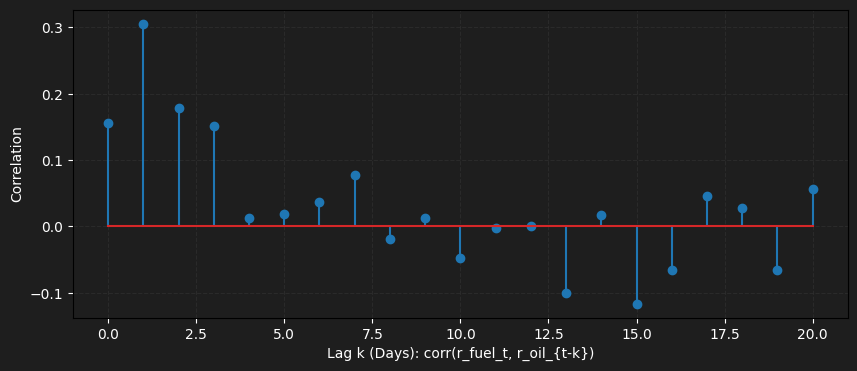

In [18]:
plt.figure(figsize=(10,4))
plt.stem(ccf_df["lag_days"], ccf_df["corr"])
plt.xlabel("Lag k (Days): corr(r_fuel_t, r_oil_{t-k})")
plt.ylabel("Correlation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

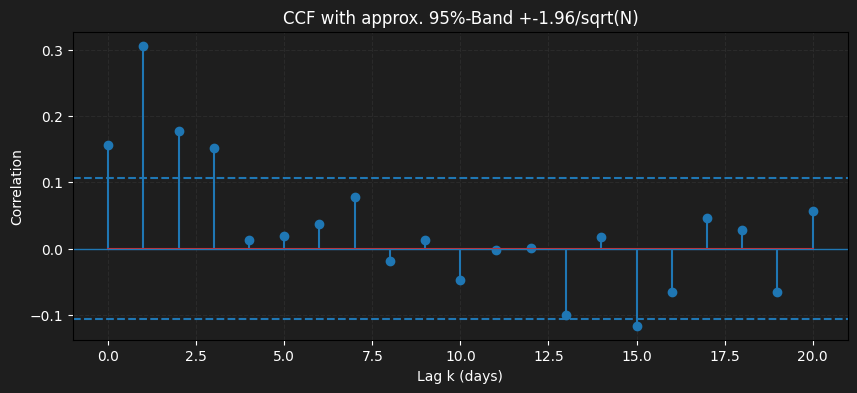

In [19]:
N = len(data)
band = 1.96 / np.sqrt(N)

plt.figure(figsize=(10,4))
plt.stem(ccf_df["lag_days"], ccf_df["corr"])
plt.axhline(0, linewidth=1)
plt.axhline(band, linestyle="--")
plt.axhline(-band, linestyle="--")
plt.title("CCF with approx. 95%-Band +-1.96/sqrt(N)")
plt.xlabel("Lag k (days)")
plt.ylabel("Correlation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

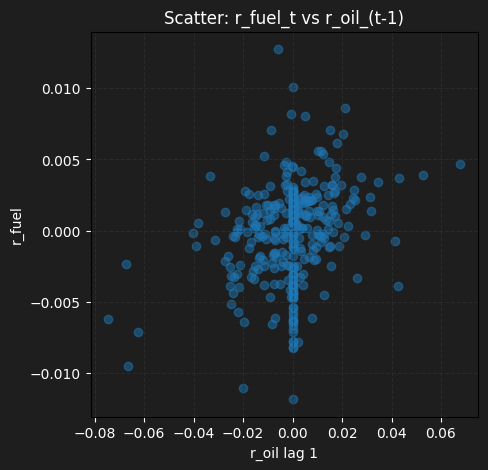

In [20]:
best_k = ccf_df.loc[ccf_df["corr"].idxmax(), "lag_days"]

k = int(1)
plt.figure(figsize=(5,5))
plt.scatter(data[f"r_oil_lag{k}"], data["r_fuel"], alpha=0.5)
plt.title(f"Scatter: r_fuel_t vs r_oil_(t-{k})")
plt.xlabel(f"r_oil lag {k}")
plt.ylabel("r_fuel")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Highest correlation between oil and fuel (e5 in this example) is 0.30 at lag k=1 for the year 2025
# ======================================

### Regression Model

To analyze how oil price changes affect fuel price changes, we estimate the following distributed lag regression:

$$
r^{fuel}_t = \alpha + \beta_0 r^{oil}_t + \beta_1 r^{oil}_{t-1} + \beta_2 r^{oil}_{t-2} + \varepsilon_t
$$

where

$$
r^{fuel}_t = \Delta \log(P^{fuel}_t)
$$

and

$$
r^{oil}_t = \Delta \log(P^{oil}_t)
$$

represent the daily log returns of fuel prices and oil prices.

The coefficients $\beta_k$ measure how oil price changes at time \(t-k\) affect fuel price changes at time \(t\).

---

### OLS Estimation

The coefficients are estimated using Ordinary Least Squares (OLS):

$$
\hat{\beta} = (X^\top X)^{-1} X^\top y
$$

where \(X\) contains the oil return lags and \(y\) contains the fuel returns.


In [21]:
import statsmodels.api as sm

X = sm.add_constant(data[lag_cols])
y = data["r_fuel"]

ols = sm.OLS(y, X).fit()

nw_lags = 7
ols_nw = ols.get_robustcov_results(cov_type="HAC", maxlags=nw_lags)

print(ols_nw.summary())

                            OLS Regression Results                            
Dep. Variable:                 r_fuel   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.173
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           2.06e-14
Time:                        17:57:44   Log-Likelihood:                 1508.2
No. Observations:                 343   AIC:                            -2972.
Df Residuals:                     321   BIC:                            -2888.
Df Model:                          21                                         
Covariance Type:                  HAC                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0001      0.000      0.792      

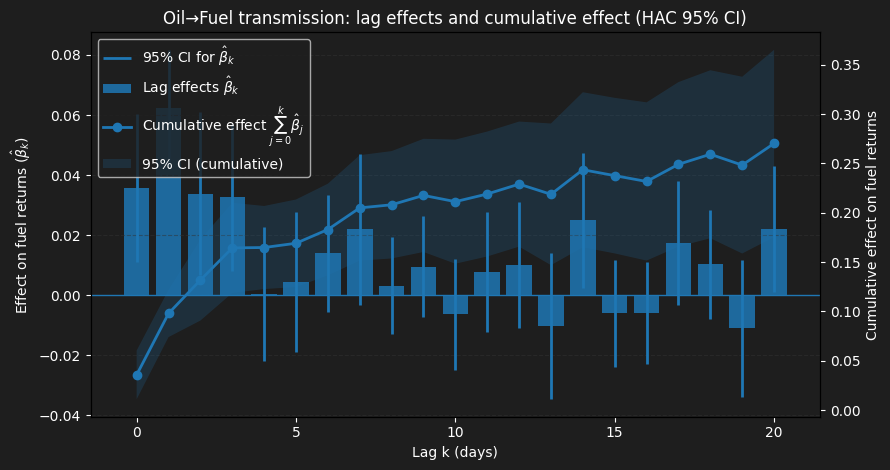

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

beta_names = [f"r_oil_lag{k}" for k in range(K+1)]
lags = np.arange(K+1)
z = 1.96

# --- make named Series / DataFrame (robust) ---
param_names = list(X.columns)  # IMPORTANT: from your regression design matrix
params = pd.Series(np.asarray(ols_nw.params), index=param_names)
bse    = pd.Series(np.asarray(ols_nw.bse),    index=param_names)

cov = pd.DataFrame(np.asarray(ols_nw.cov_params()), index=param_names, columns=param_names)

# --- extract betas + SE for lag terms ---
b  = params[beta_names].to_numpy()
se = bse[beta_names].to_numpy()

ci_low  = b - z*se
ci_high = b + z*se

# cumulative effects
cum = np.cumsum(b)

# proper CI for cumulative using covariance (includes covariances!)
cum_se = []
for k in range(K+1):
    sub = cov.loc[beta_names[:k+1], beta_names[:k+1]].to_numpy()
    ones = np.ones(k+1)
    var_cum = ones @ sub @ ones
    cum_se.append(np.sqrt(var_cum))
cum_se = np.array(cum_se)

cum_low  = cum - z*cum_se
cum_high = cum + z*cum_se

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(9, 4.8))

# Bars for beta_k
ax1.bar(lags, b, alpha=0.85, label=r"Lag effects $\hat{\beta}_k$")
# Error bars as vertical lines
ax1.vlines(lags, ci_low, ci_high, linewidth=2, label=r"95% CI for $\hat{\beta}_k$")
ax1.axhline(0, linewidth=1)

ax1.set_xlabel("Lag k (days)")
ax1.set_ylabel(r"Effect on fuel returns ($\hat{\beta}_k$)")
ax1.set_title("Oil→Fuel transmission: lag effects and cumulative effect (HAC 95% CI)")
ax1.grid(True, axis="y", linestyle="--", alpha=0.5)

# Second axis for cumulative effect
ax2 = ax1.twinx()
ax2.plot(lags, cum, marker="o", linewidth=2, label=r"Cumulative effect $\sum_{j=0}^k \hat{\beta}_j$")
ax2.fill_between(lags, cum_low, cum_high, alpha=0.2, label="95% CI (cumulative)")
ax2.set_ylabel(r"Cumulative effect on fuel returns")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.tight_layout()
plt.show()